# Day 2 — Parallel Execution, Streaming, and Human-in-the-Loop

**Time:** about 90 minutes  
**Build:** run graph branches in parallel, stream a bounded loop's progress, then let a person decide at each step.  
**Focus:** how a graph *runs* — concurrent branches, when the caller sees progress, and who decides whether the loop continues.

Day 1 built graphs that run one node at a time. Today we look at three ways execution can differ:

1. **Parallel execution** — several nodes run at once, and a reducer merges their writes.
2. **Streaming** — surface each step as its node finishes, instead of waiting for the final state.
3. **Human-in-the-loop** — a `human_review` node pauses the graph with `interrupt()` and resumes on `Command(resume=...)`; the loop runs at least three and at most five steps, with deterministic code as the final guard.

Before running the notebook, complete the shared setup in the repository's main `README.md` and start MLflow.

## 1. Connect to the shared MLflow Gateway

In [1]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="http://127.0.0.1:5001/gateway/mlflow/v1",
    api_key="not-needed",
    model="workshop-gemini",
)

## 2. Define the running example and shared imports

Day 1 imported these types while building its graphs. This notebook stands on its own, so we import the shared types once and restate the running knapsack bug here.

In [2]:
from typing import Annotated, Literal, TypedDict
from operator import add
from pydantic import BaseModel
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."

buggy_code = """
n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])
"""

In [3]:
from typing import Annotated, Literal, TypedDict
from operator import add
from pydantic import BaseModel
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."

buggy_code = """
n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])
"""

## 3. Define the debug step

Both parts below reuse this step. Like Day 1's retry step, it is a plain `diagnosis` and `fix` plus a `continue_loop` flag that says whether another bug may remain — simple enough to print in a stream and clear enough for a human to judge.

In [4]:
DEBUG_PROMPT = """
Debug the Python code. Review the previous steps before answering.
Give the best diagnosis and the smallest fix.
Set continue_loop to true only if another bug may remain.
Do not repeat a bug already found in the previous steps.
"""

class DebugStep(BaseModel):
    diagnosis: str
    fix: str
    continue_loop: bool

step_llm = llm.with_structured_output(DebugStep)

# Part 1 — Parallel execution

LangGraph runs the graph in **supersteps**: every node ready at the same time runs together, concurrently. Here three specialists have an edge straight from `START`, so they **fan out** and run at once; `finalize` has an edge from each, so it **fans in** and waits for all three.

Because three nodes write the **same** state key (`diagnoses`) in one superstep, that key needs a **reducer**. `Annotated[list, add]` tells LangGraph to merge concurrent writes by concatenation instead of raising a conflict.

## 4. Build a fan-out graph

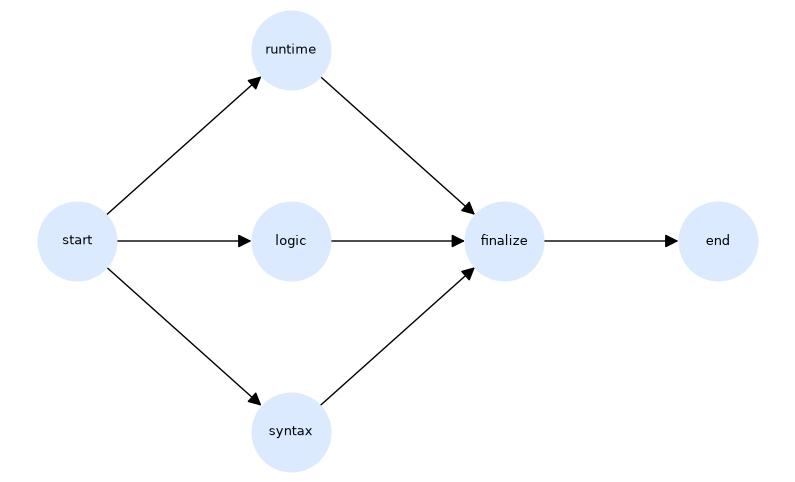

In [5]:
SPECIALIST_PROMPT = "You are a {category} bug specialist. Give the root cause in one sentence. Do not invent missing context."

class Diagnosis(BaseModel):
    category: str
    cause: str

specialist_llm = llm.with_structured_output(Diagnosis)

class ParallelState(TypedDict):
    problem: str
    code: str
    diagnoses: Annotated[list, add]   # reducer: merges concurrent writes
    answer: str

def make_specialist(category: str):
    def node(state: ParallelState):
        result = specialist_llm.invoke([
            {"role": "system", "content": SPECIALIST_PROMPT.format(category=category)},
            {"role": "user", "content": f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}"},
        ])
        return {"diagnoses": [f"[{category}] {result.cause}"]}
    return node

def finalize(state: ParallelState):
    return {"answer": "\n".join(state["diagnoses"])}

builder = StateGraph(ParallelState)
builder.add_node("syntax", make_specialist("syntax"))
builder.add_node("runtime", make_specialist("runtime"))
builder.add_node("logic", make_specialist("logic"))
builder.add_node("finalize", finalize)

for name in ["syntax", "runtime", "logic"]:
    builder.add_edge(START, name)       # fan-out: three nodes start in one superstep
    builder.add_edge(name, "finalize")  # fan-in: finalize waits for all three

builder.add_edge("finalize", END)
parallel_graph = builder.compile()
show_graph(parallel_graph)

## 5. Merge concurrent writes with a reducer

In [6]:
parallel_result = parallel_graph.invoke({
    "problem": problem_statement,
    "code": buggy_code,
    "diagnoses": [],
})

assert len(parallel_result["diagnoses"]) == 3
print(parallel_result["answer"])

[logic] The inner loop iterates forward (from `weight` to `capacity`), which allows the same item to be used multiple times (unbounded knapsack); it should iterate backward (from `capacity` down to `weight`) to ensure each item is selected at most once (0/1 knapsack).
[runtime] The inner loop iterates forward (from `weight` to `capacity`), which allows the same item to be counted multiple times (unbounded knapsack behavior); it should iterate in reverse (from `capacity` down to `weight`) to ensure each item is used at most once.
[syntax] The inner loop iterates forward (`range(weight, capacity + 1)`), which allows an item to be reused multiple times (unbounded knapsack); it must iterate in reverse (`range(capacity, weight - 1, -1)`) to ensure each item is selected at most once (0/1 knapsack).


## Break, inspect, reflect

Drop the reducer — make `diagnoses` a plain `list` — and rerun. Three nodes writing the same key in one superstep now raise `InvalidUpdateError`; the reducer is what makes fan-out safe. Restore it before continuing.

# Part 2 — Streaming Progress

`invoke()` returns only the final state, after every node has run. A multi-step loop can take many seconds, and a person watching learns nothing until it finishes.

`stream()` yields an ordered update as **each node finishes**, so a caller can show progress immediately. The same graph supports several stream modes:

- `updates` — the state change each node returns (used below).
- `values` — the full state after each step.
- `messages` — token-by-token model output.

This is the in-process version of a progress stream. Day 7 puts the same idea behind an HTTP endpoint as **Server-Sent Events (SSE)**, so a browser can render each step as it arrives.

## 6. Build a streaming loop

We put the debug step in a self-loop bounded by `limit`, so the whole run streams to completion. The router is deterministic: keep looping while the last step asks to continue and the limit is not reached.

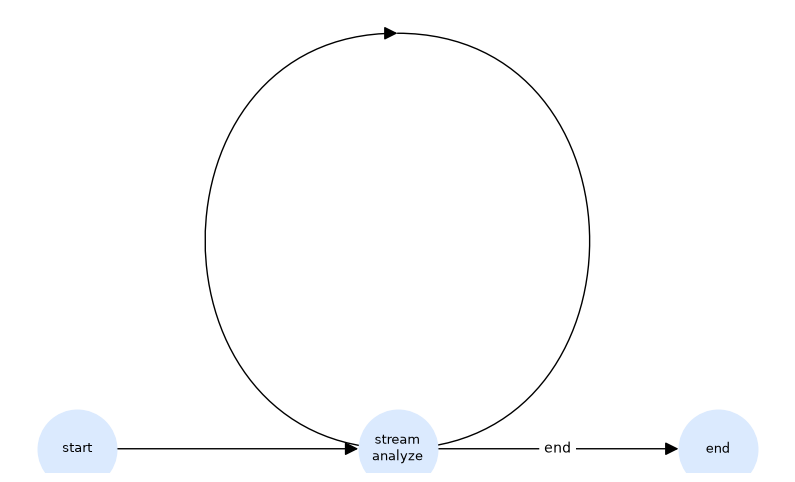

In [8]:
class StreamState(TypedDict):
    problem: str
    code: str
    iteration: int
    limit: int
    steps: list[dict]

def stream_analyze(state: StreamState):
    step = step_llm.invoke([
        {"role": "system", "content": DEBUG_PROMPT},
        {"role": "user", "content": f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}\n\nPrevious steps:\n{state['steps']}"},
    ])
    return {
        "iteration": state["iteration"] + 1,
        "steps": state["steps"] + [step.model_dump()],
    }

def stream_route(state: StreamState) -> Literal["stream_analyze", "end"]:
    if state["iteration"] >= state["limit"]:
        return "end"
    if state["iteration"] >= 3 and not state["steps"][-1]["continue_loop"]:
        return "end"
    return "stream_analyze"

builder = StateGraph(StreamState)
builder.add_node("stream_analyze", stream_analyze)
builder.add_edge(START, "stream_analyze")
builder.add_conditional_edges("stream_analyze", stream_route, {"stream_analyze": "stream_analyze", "end": END})
stream_graph = builder.compile()
show_graph(stream_graph)

## 7. Stream ordered progress updates

`stream_mode="updates"` yields one chunk per node as it completes, shaped as `{node_name: state_update}`. Read each chunk the moment it arrives instead of waiting for the final state.

The router runs the loop at least three times and at most five, so you always see several updates before it stops.

In [ ]:
final = None
for chunk in stream_graph.stream(
    {"problem": problem_statement, "code": buggy_code, "iteration": 0, "limit": 5, "steps": []},
    stream_mode="updates",
):
    node, update = next(iter(chunk.items()))
    latest = update["steps"][-1]
    print(f"[{node}] step {update['iteration']}: {latest['diagnosis']}")
    final = update

assert final is not None and 3 <= final["iteration"] <= 5
print("\nStream finished after", final["iteration"], "step(s).")

{'stream_analyze': {'iteration': 1, 'steps': [{'diagnosis': 'The inner loop iterates forward (range(weight, capacity + 1)), which allows an item to be used multiple times (unbounded knapsack). For 0/1 knapsack, the loop must go in reverse so each item is only considered once.', 'fix': 'Change `for current in range(weight, capacity + 1):` to `for current in range(capacity, weight - 1, -1):`', 'continue_loop': False}]}}
[stream_analyze] step 1: The inner loop iterates forward (range(weight, capacity + 1)), which allows an item to be used multiple times (unbounded knapsack). For 0/1 knapsack, the loop must go in reverse so each item is only considered once.
{'stream_analyze': {'iteration': 2, 'steps': [{'diagnosis': 'The inner loop iterates forward (range(weight, capacity + 1)), which allows an item to be used multiple times (unbounded knapsack). For 0/1 knapsack, the loop must go in reverse so each item is only considered once.', 'fix': 'Change `for current in range(weight, capacity + 1)

## Break, inspect, reflect

Change `stream_mode` to `"values"` and print `chunk["iteration"]` each step. Notice that `updates` shows only what a node changed, while `values` repeats the full state every step. Then run the same graph through `invoke()` and compare what you see.

**Exit question:** Streaming lets a caller display progress as it happens. Does streaming change what the graph computes, or only when the caller sees it?

# Part 3 — Human-in-the-Loop Review

The streaming loop ran to completion on its own. Now a person reviews each step and decides whether the loop may try again or must stop. LangGraph pauses the graph with `interrupt()` and resumes it later from that exact point, so the pause can last as long as the human needs.

We keep the same debug step and add one new node, `human_review`, that pauses after every step.

## 8. Add a `human_review` node that pauses with `interrupt()`

`interrupt()` stops the node and sends a JSON-serializable payload out of the graph — here, the latest diagnosis and fix. The graph does not resume on its own; the caller must invoke it again with `Command(resume=...)`, and that resume value becomes the return value of `interrupt()` inside the node.

A pause has to survive between two separate `invoke` calls, so the graph needs a checkpointer. `MemorySaver` keeps that state in memory, keyed by a `thread_id` that every `invoke` call for this run must share. Because the checkpointer serializes every field, `steps` stores plain dicts (`step.model_dump()`), not `DebugStep` objects.

`human_review` makes its routing decision with `Command(goto=...)` instead of `add_conditional_edges`. Nothing happens in the node before the `interrupt()` call — if a model call ran first, it would run again every time the node resumes.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

class HumanLoopState(TypedDict):
    problem: str
    code: str
    iteration: int
    limit: int
    steps: list[dict]

def hl_analyze(state: HumanLoopState):
    step = step_llm.invoke([
        {"role": "system", "content": DEBUG_PROMPT},
        {"role": "user", "content": f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}\n\nPrevious steps:\n{state['steps']}"},
    ])
    return {
        "iteration": state["iteration"] + 1,
        "steps": state["steps"] + [step.model_dump()],
    }

def human_review(state: HumanLoopState) -> Command[Literal["hl_analyze", "__end__"]]:
    latest = state["steps"][-1]
    decision = interrupt({
        "question": "Try again or end?",
        "iteration": state["iteration"],
        "diagnosis": latest["diagnosis"],
        "fix": latest["fix"],
        "continue_loop": latest["continue_loop"],
    })

    if state["iteration"] < 3:
        return Command(goto="hl_analyze")   # at least three steps
    if decision == "retry" and state["iteration"] < state["limit"]:
        return Command(goto="hl_analyze")
    return Command(goto=END)

builder = StateGraph(HumanLoopState)
builder.add_node("hl_analyze", hl_analyze)
builder.add_node("human_review", human_review)
builder.add_edge(START, "hl_analyze")
builder.add_edge("hl_analyze", "human_review")

hl_graph = builder.compile(checkpointer=MemorySaver())
show_graph(hl_graph)

## 9. Run the loop and decide at each pause

`invoke` returns as soon as the graph pauses. LangGraph reports the pause as a `__interrupt__` key holding the payload passed to `interrupt()`; that key is absent once the graph reaches `END`. Read the diagnosis, type a real decision, and resume with `Command(resume=decision)` using the same `thread_id`.

The loop runs **at least three and at most five** steps: your first two answers cannot end it, and it stops at the fifth even if you keep answering `retry`. Before running, predict how many times you will be asked.

In [ ]:
import json

thread_config = {"configurable": {"thread_id": "day-2-human-loop"}}

result = hl_graph.invoke({
    "problem": problem_statement,
    "code": buggy_code,
    "iteration": 0,
    "limit": 5,
    "steps": [],
}, config=thread_config)

while "__interrupt__" in result:
    pause = result["__interrupt__"][0].value
    print(f"\n--- Step {pause['iteration']} ---")
    print("Diagnosis:", pause["diagnosis"])
    print("Fix:", pause["fix"])

    answer = input("Type 'retry' to let the agent try again, anything else to end: ").strip().lower()
    result = hl_graph.invoke(Command(resume=answer), config=thread_config)

assert 3 <= result["iteration"] <= 5
print("\nStopped after", result["iteration"], "step(s).")
print(json.dumps(result["steps"][-1], indent=2))

## Break, inspect, reflect

Answer `retry` every time and confirm the graph still stops at the fifth step; then answer `end` at the very first pause and confirm it keeps going until the third. Deterministic code owns the bound, not your answers. Then remove the checkpointer from `compile()` and try resuming again.

**Exit question:** `interrupt()` re-runs its node from the first line every time that node resumes. Why does `human_review` place the `interrupt()` call before any other work, and what would go wrong if `hl_analyze` tried to pause the same way?